# ML/DL에 사용하는 함수들

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

%matplotlib inline

x = np.arange(1, 11, 0.1)
x


array([ 1. ,  1.1,  1.2,  1.3,  1.4,  1.5,  1.6,  1.7,  1.8,  1.9,  2. ,
        2.1,  2.2,  2.3,  2.4,  2.5,  2.6,  2.7,  2.8,  2.9,  3. ,  3.1,
        3.2,  3.3,  3.4,  3.5,  3.6,  3.7,  3.8,  3.9,  4. ,  4.1,  4.2,
        4.3,  4.4,  4.5,  4.6,  4.7,  4.8,  4.9,  5. ,  5.1,  5.2,  5.3,
        5.4,  5.5,  5.6,  5.7,  5.8,  5.9,  6. ,  6.1,  6.2,  6.3,  6.4,
        6.5,  6.6,  6.7,  6.8,  6.9,  7. ,  7.1,  7.2,  7.3,  7.4,  7.5,
        7.6,  7.7,  7.8,  7.9,  8. ,  8.1,  8.2,  8.3,  8.4,  8.5,  8.6,
        8.7,  8.8,  8.9,  9. ,  9.1,  9.2,  9.3,  9.4,  9.5,  9.6,  9.7,
        9.8,  9.9, 10. , 10.1, 10.2, 10.3, 10.4, 10.5, 10.6, 10.7, 10.8,
       10.9])

In [21]:
y = np.exp(x)
y

array([2.71828183e+00, 3.00416602e+00, 3.32011692e+00, 3.66929667e+00,
       4.05519997e+00, 4.48168907e+00, 4.95303242e+00, 5.47394739e+00,
       6.04964746e+00, 6.68589444e+00, 7.38905610e+00, 8.16616991e+00,
       9.02501350e+00, 9.97418245e+00, 1.10231764e+01, 1.21824940e+01,
       1.34637380e+01, 1.48797317e+01, 1.64446468e+01, 1.81741454e+01,
       2.00855369e+01, 2.21979513e+01, 2.45325302e+01, 2.71126389e+01,
       2.99641000e+01, 3.31154520e+01, 3.65982344e+01, 4.04473044e+01,
       4.47011845e+01, 4.94024491e+01, 5.45981500e+01, 6.03402876e+01,
       6.66863310e+01, 7.36997937e+01, 8.14508687e+01, 9.00171313e+01,
       9.94843156e+01, 1.09947172e+02, 1.21510418e+02, 1.34289780e+02,
       1.48413159e+02, 1.64021907e+02, 1.81272242e+02, 2.00336810e+02,
       2.21406416e+02, 2.44691932e+02, 2.70426407e+02, 2.98867401e+02,
       3.30299560e+02, 3.65037468e+02, 4.03428793e+02, 4.45857770e+02,
       4.92749041e+02, 5.44571910e+02, 6.01845038e+02, 6.65141633e+02,
      

<Axes: >

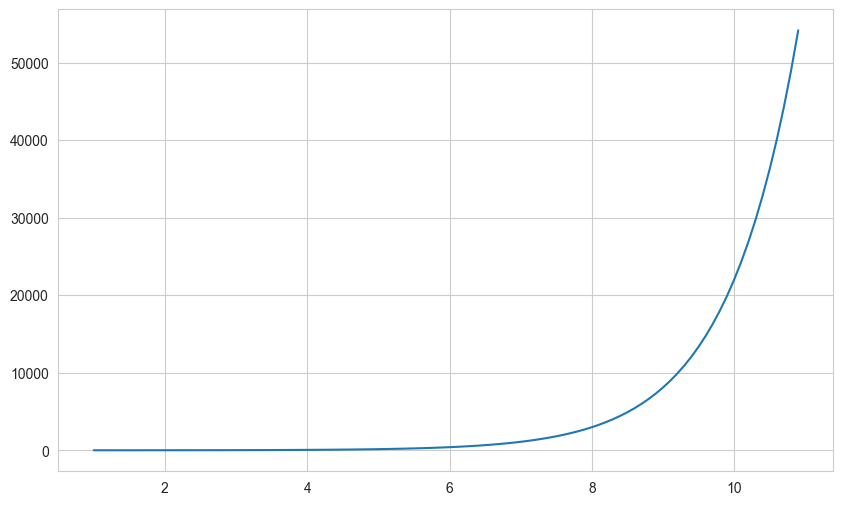

In [22]:
plt.figure(figsize=(10,6))
sns.lineplot(x=x, y=y)

In [92]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [93]:
x = np.arange(-10, 10, 0.1)
y = sigmoid(x)

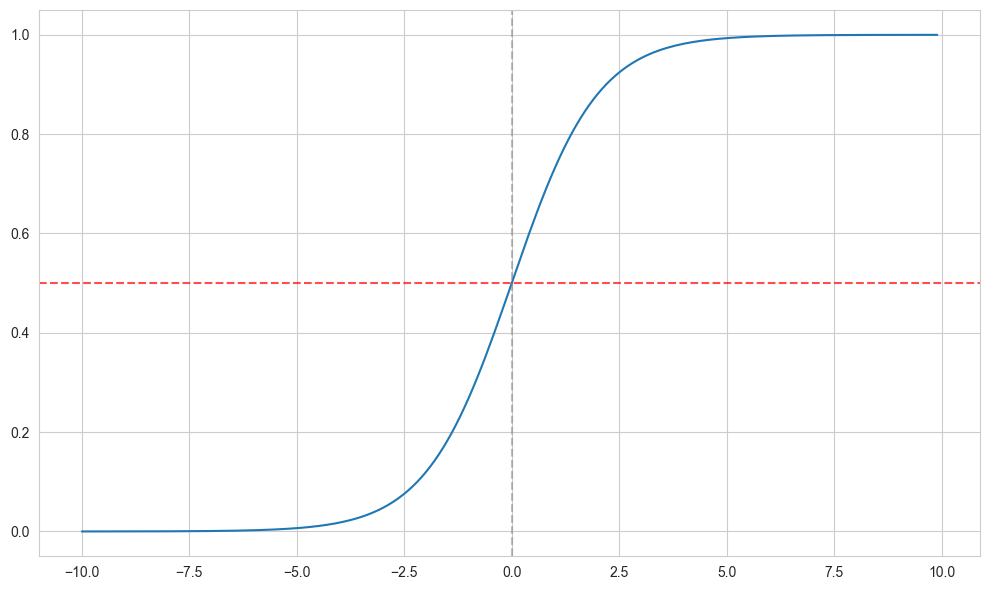

In [95]:
plt.figure(figsize=(10, 6))
plt.plot(x, y)           # x축을 인덱스로
# 기준선: 확률 0.5 (분류 경계)
plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.7, label='확률 = 0.5 (분류 경계)')
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

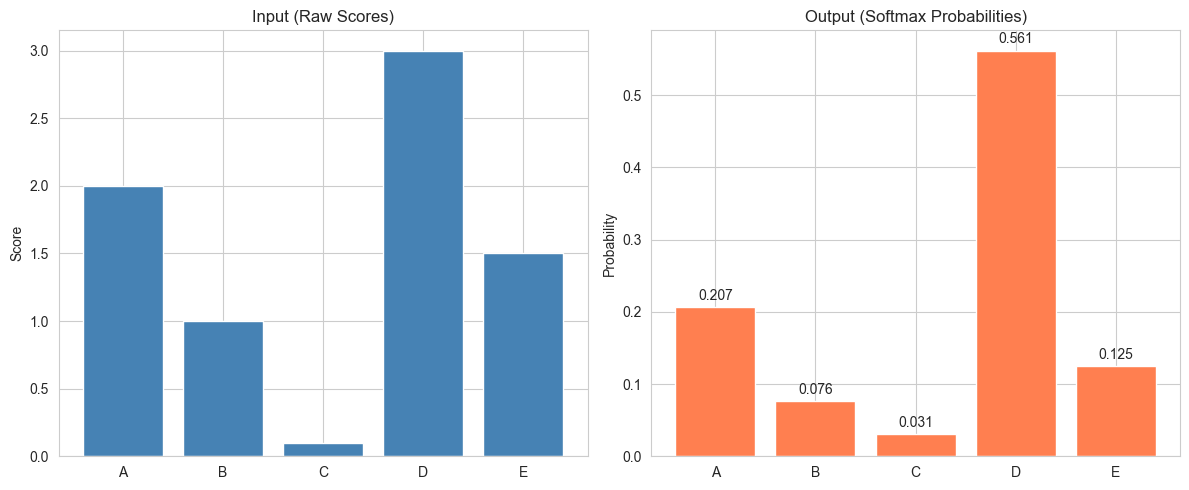

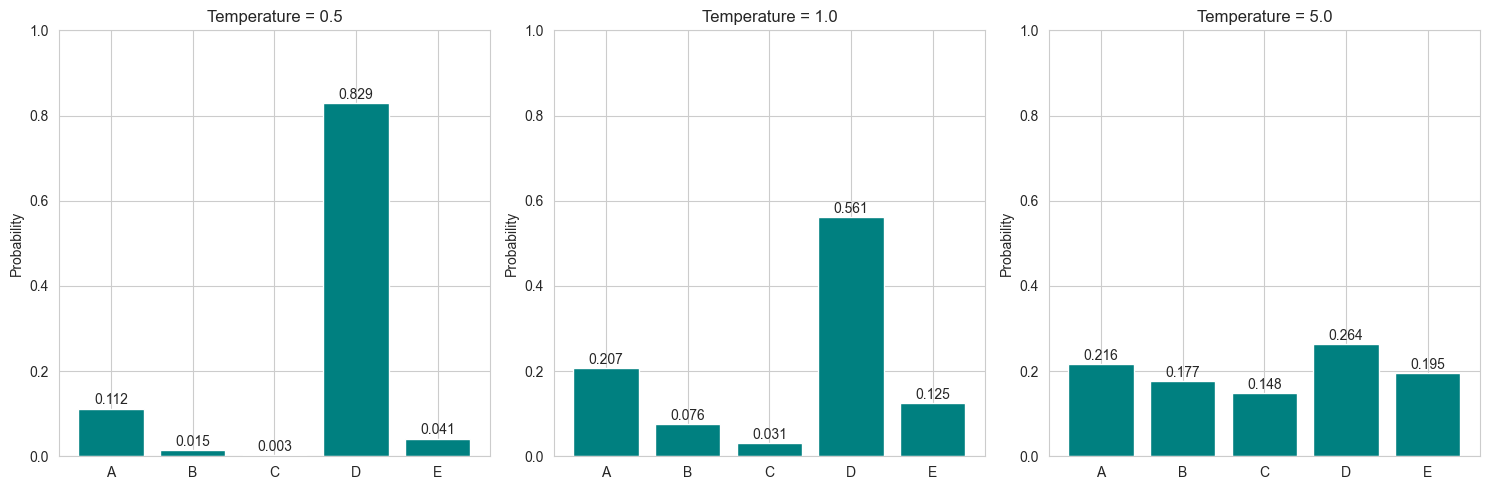

In [96]:
# softmax 함수 정의
def softmax(x):
  exp_x = np.exp(x - np.max(x))  # overflow 방지
  return exp_x / np.sum(exp_x)

# 1. softmax 입력 vs 출력 비교
scores = np.array([2.0, 1.0, 0.1, 3.0, 1.5])
probs = softmax(scores)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

labels = ['A', 'B', 'C', 'D', 'E']
axes[0].bar(labels, scores, color='steelblue')
axes[0].set_title('Input (Raw Scores)')
axes[0].set_ylabel('Score')

axes[1].bar(labels, probs, color='coral')
axes[1].set_title('Output (Softmax Probabilities)')
axes[1].set_ylabel('Probability')
for i, p in enumerate(probs):
  axes[1].text(i, p + 0.01, f'{p:.3f}', ha='center')

plt.tight_layout()
plt.show()

# 2. 온도(temperature)에 따른 softmax 변화
def softmax_temp(x, T):
  exp_x = np.exp((x - np.max(x)) / T)
  return exp_x / np.sum(exp_x)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
temperatures = [0.5, 1.0, 5.0]

for ax, T in zip(axes, temperatures):
  probs = softmax_temp(scores, T)
  ax.bar(labels, probs, color='teal')
  ax.set_title(f'Temperature = {T}')
  ax.set_ylabel('Probability')
  ax.set_ylim(0, 1)
  for i, p in enumerate(probs):
    ax.text(i, p + 0.01, f'{p:.3f}', ha='center')

plt.tight_layout()
plt.show()
